<a href="https://colab.research.google.com/github/IshaCodex/OIBSIP/blob/main/DataAnalytics-L2-PlayStoreAnalysis/Task4_Play_Store_Analysis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
!pip install textblob

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
from textblob import TextBlob

# Load the datasets
df_apps = pd.read_csv('/content/googleplaystore.csv')
df_reviews = pd.read_csv('/content/googleplaystore_user_reviews.csv')

# Data Cleaning: Handling Nulls and Duplicates

The Play Store dataset contains duplicate entries for some apps. We will drop these duplicates and remove rows with missing critical data (like Ratings).

In [3]:
# Remove duplicate apps
df_apps = df_apps.drop_duplicates(subset=['App'], keep='first')

# Drop rows with null values in critical columns
df_apps = df_apps.dropna(subset=['Rating', 'Type', 'Content Rating', 'Current Ver', 'Android Ver'])

# Data Cleaning: Fixing Data Types ('Installs')

The 'Installs' column is currently a string with commas and plus signs (e.g., "10,000+"). We need to strip these characters and convert the column to an integer for mathematical analysis.

In [4]:
# Clean the 'Installs' column
df_apps['Installs'] = df_apps['Installs'].str.replace('+', '', regex=False)
df_apps['Installs'] = df_apps['Installs'].str.replace(',', '', regex=False)

# Catch any irregular string values and convert to integer
df_apps['Installs'] = df_apps['Installs'].replace('Free', '0')
df_apps['Installs'] = df_apps['Installs'].astype(int)

# Data Cleaning: Fixing Data Types ('Price')

The 'Price' column contains dollar signs, causing pandas to read it as text. We will remove the symbol and convert it to a float.

In [5]:
# Clean the 'Price' column
df_apps['Price'] = df_apps['Price'].str.replace('$', '', regex=False)
df_apps['Price'] = df_apps['Price'].replace('Everyone', '0')
df_apps['Price'] = df_apps['Price'].astype(float)

# Data Cleaning: Standardizing App 'Size'

App sizes are represented as strings with 'M' for megabytes and 'k' for kilobytes. We will create a function to convert everything into a standardized float format (Megabytes), and impute the median for apps listed as "Varies with device".

In [6]:
def clean_size(size_str):
    if size_str == 'Varies with device':
        return np.nan
    elif 'M' in str(size_str):
        return float(size_str.replace('M', ''))
    elif 'k' in str(size_str):
        return float(size_str.replace('k', '')) / 1024
    else:
        return np.nan

# Apply the function and fill missing values with the median size
df_apps['Size'] = df_apps['Size'].apply(clean_size)
df_apps['Size'] = df_apps['Size'].fillna(df_apps['Size'].median())

# Category Analysis

We will visualize the distribution of apps across various categories to identify the most saturated markets on the Play Store.

/tmp/ipykernel_1895/2223570877.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(y='Category', data=df_apps, order=df_apps['Category'].value_counts().index, palette='viridis')


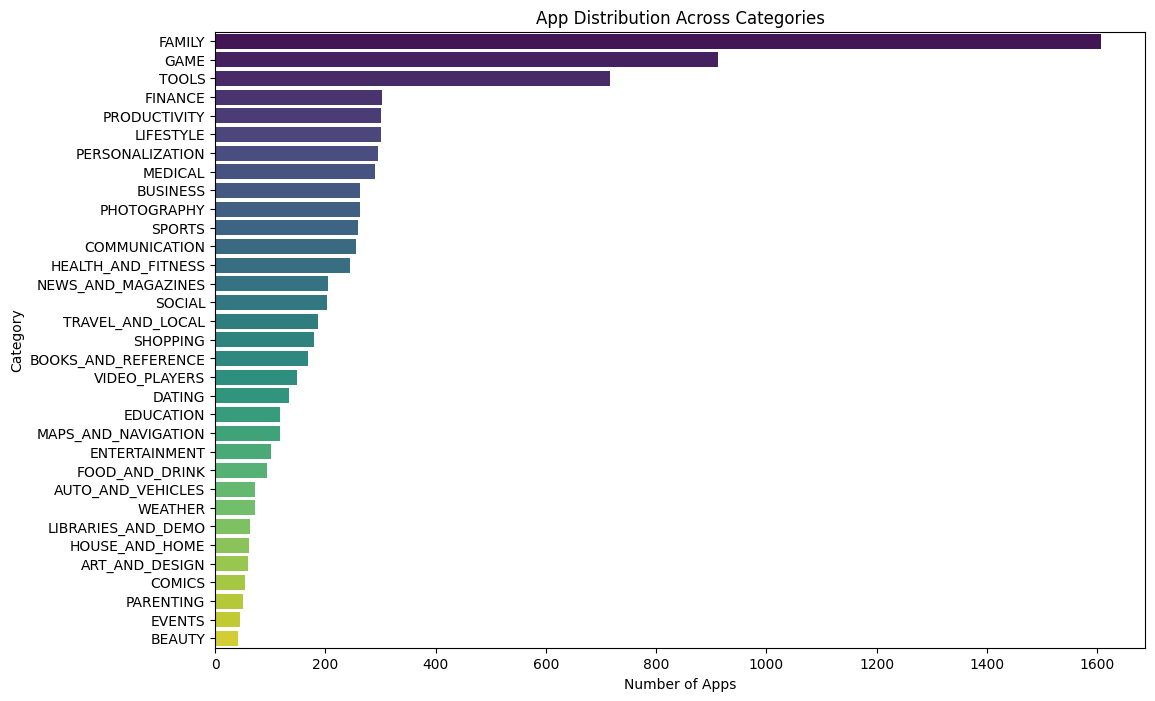

In [7]:
plt.figure(figsize=(12, 8))
sns.countplot(y='Category', data=df_apps, order=df_apps['Category'].value_counts().index, palette='viridis')
plt.title('App Distribution Across Categories')
plt.xlabel('Number of Apps')
plt.ylabel('Category')
plt.show()

# Ratings Analysis

Let's analyze how apps are rated generally across the store, followed by a breakdown of average ratings by specific categories.

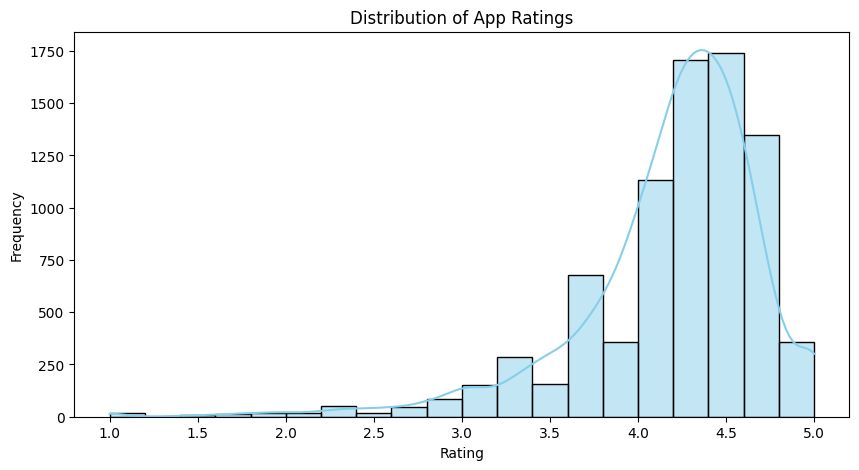

In [8]:
plt.figure(figsize=(10, 5))
sns.histplot(df_apps['Rating'], bins=20, kde=True, color='skyblue')
plt.title('Distribution of App Ratings')
plt.xlabel('Rating')
plt.ylabel('Frequency')
plt.show()

Calculating and plotting the average rating by category.

/tmp/ipykernel_1895/733021350.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=avg_rating.values, y=avg_rating.index, palette='magma')


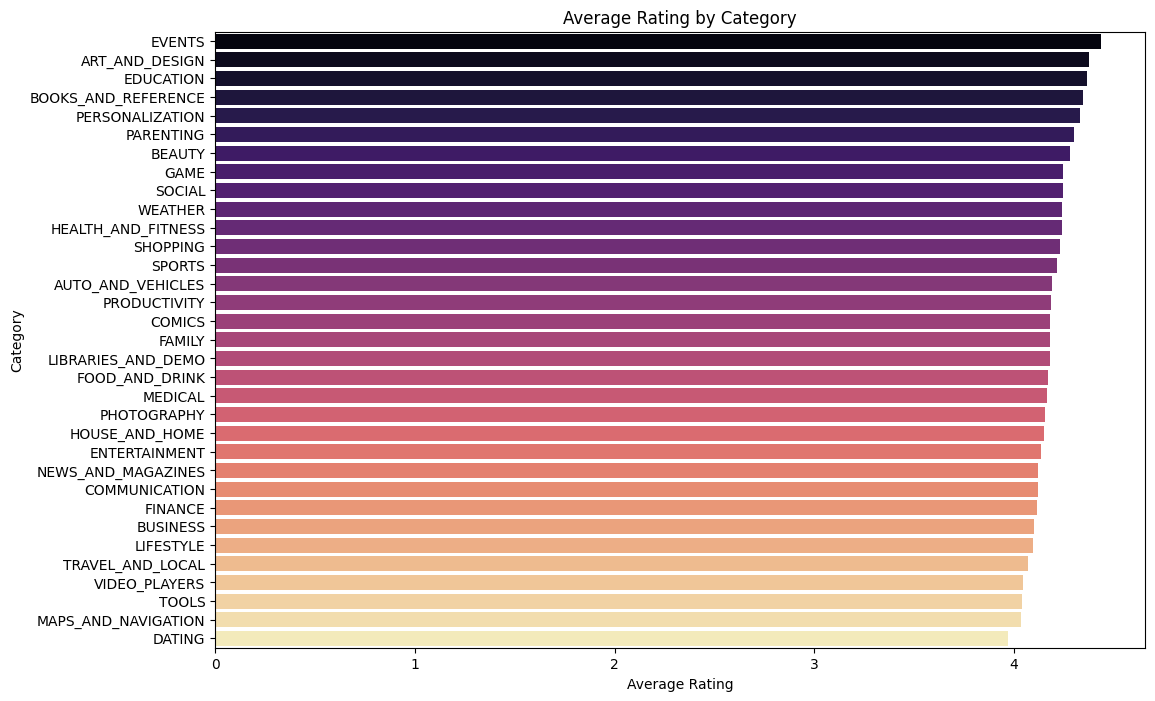

In [9]:
avg_rating = df_apps.groupby('Category')['Rating'].mean().sort_values(ascending=False)

plt.figure(figsize=(12, 8))
sns.barplot(x=avg_rating.values, y=avg_rating.index, palette='magma')
plt.title('Average Rating by Category')
plt.xlabel('Average Rating')
plt.ylabel('Category')
plt.show()

# Size vs. Installs Analysis

We will use a scatter plot to determine if an app's file size impacts the likelihood of users downloading it. We use a logarithmic scale for installs due to extreme outliers.

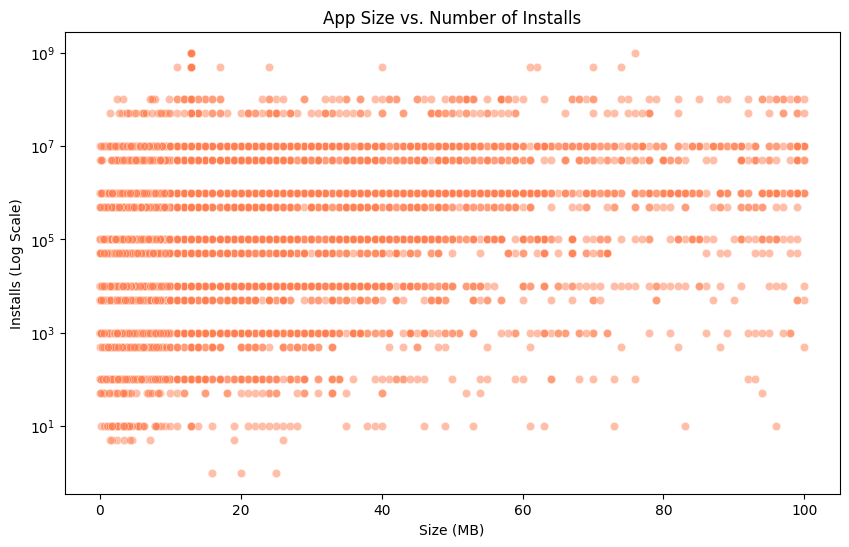

In [10]:
plt.figure(figsize=(10, 6))
sns.scatterplot(x='Size', y='Installs', data=df_apps, alpha=0.5, color='coral')
plt.title('App Size vs. Number of Installs')
plt.xlabel('Size (MB)')
plt.ylabel('Installs (Log Scale)')
plt.yscale('log')
plt.show()

# Pricing Analysis

We will analyze the pricing structure of the Play Store, starting with the ratio of free versus paid apps, followed by the price distribution of paid apps.

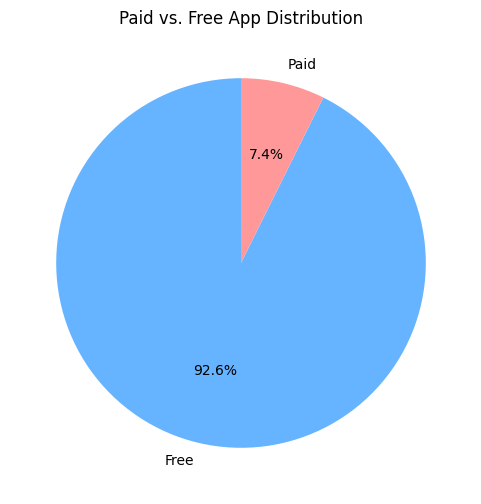

In [11]:
type_counts = df_apps['Type'].value_counts()

plt.figure(figsize=(6, 6))
plt.pie(type_counts, labels=type_counts.index, autopct='%1.1f%%', colors=['#66b3ff', '#ff9999'], startangle=90)
plt.title('Paid vs. Free App Distribution')
plt.show()

Visualizing the distribution of prices specifically for apps that cost money.

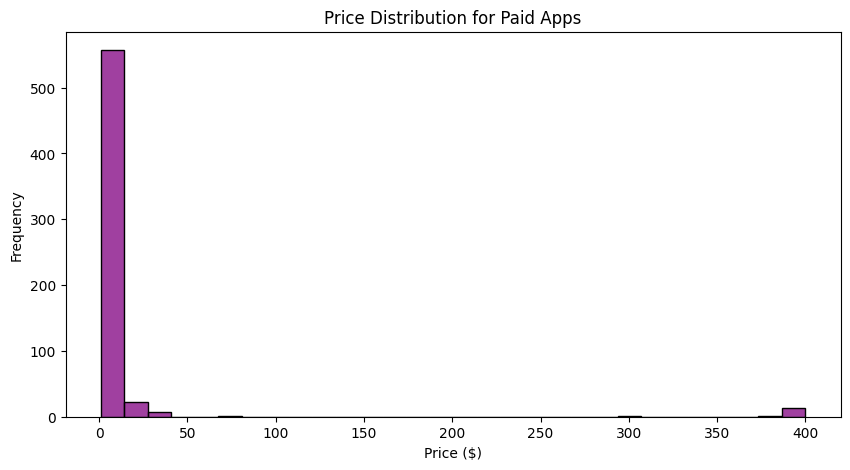

In [12]:
paid_apps = df_apps[df_apps['Type'] == 'Paid']

plt.figure(figsize=(10, 5))
sns.histplot(paid_apps['Price'], bins=30, kde=False, color='purple')
plt.title('Price Distribution for Paid Apps')
plt.xlabel('Price ($)')
plt.ylabel('Frequency')
plt.show()

We will calculate estimated revenue (Price multiplied by Installs) to see which categories generate the highest direct sales volume.

/tmp/ipykernel_1895/747404410.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=revenue_cat.values, y=revenue_cat.index, palette='Greens_r')


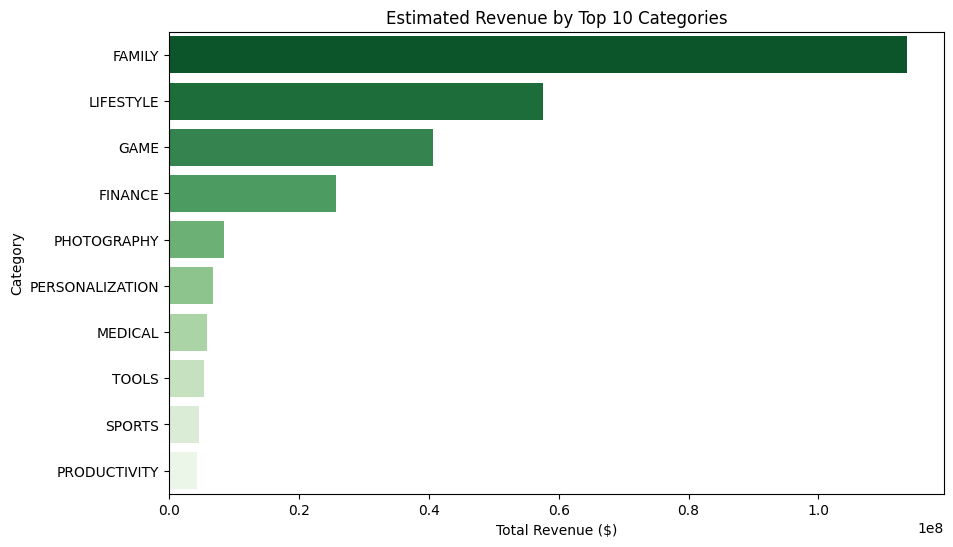

In [13]:
df_apps['Estimated_Revenue'] = df_apps['Price'] * df_apps['Installs']
revenue_cat = df_apps.groupby('Category')['Estimated_Revenue'].sum().sort_values(ascending=False).head(10)

plt.figure(figsize=(10, 6))
sns.barplot(x=revenue_cat.values, y=revenue_cat.index, palette='Greens_r')
plt.title('Estimated Revenue by Top 10 Categories')
plt.xlabel('Total Revenue ($)')
plt.ylabel('Category')
plt.show()

# Sentiment Analysis on User Reviews

Using the NLP library TextBlob, we will calculate the sentiment polarity of user reviews to classify them as Positive, Negative, or Neutral.

In [14]:
# Drop rows with missing text reviews
df_reviews = df_reviews.dropna(subset=['Translated_Review'])

def get_sentiment(text):
    polarity = TextBlob(str(text)).sentiment.polarity
    if polarity > 0:
        return 'Positive'
    elif polarity < 0:
        return 'Negative'
    else:
        return 'Neutral'

# Apply the NLP function to classify the reviews
df_reviews['Calculated_Sentiment'] = df_reviews['Translated_Review'].apply(get_sentiment)
print("Sentiment classification completed.")

Sentiment classification completed.


# Sentiment by Category

By merging our apps dataset with our calculated reviews dataset, we can identify which app categories generate the most positive and negative feedback from users.

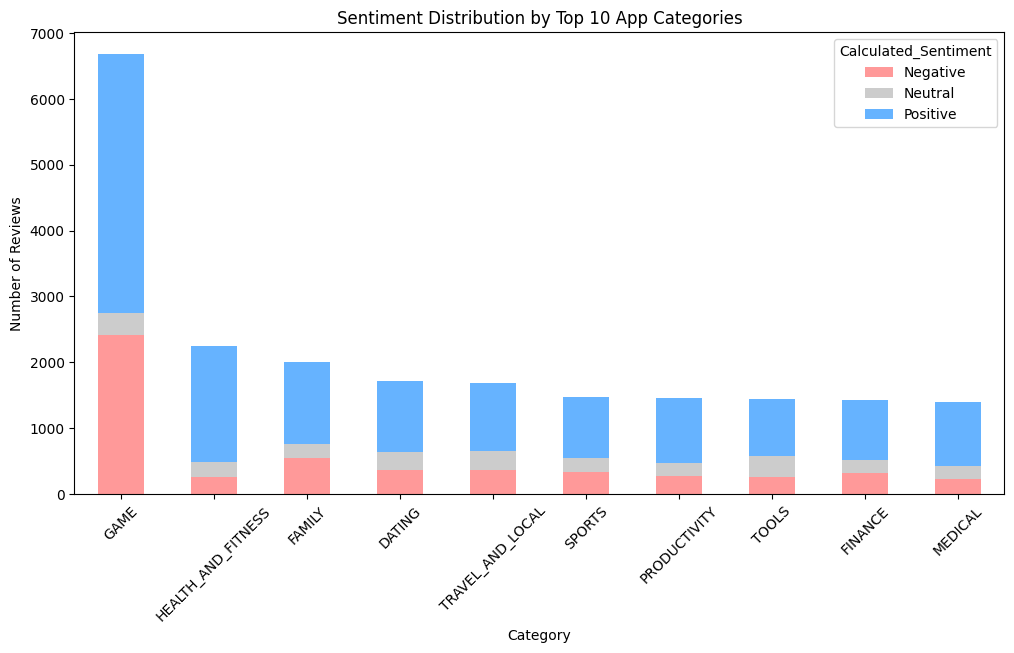

In [15]:
# Merge datasets on the 'App' name
merged_df = pd.merge(df_apps, df_reviews, on='App', how='inner')

# Group by category and sentiment
sentiment_cat = merged_df.groupby(['Category', 'Calculated_Sentiment']).size().unstack().fillna(0)

# Get top 10 categories with the most overall reviews
top_cats = sentiment_cat.sum(axis=1).sort_values(ascending=False).head(10).index
sentiment_top = sentiment_cat.loc[top_cats]

sentiment_top.plot(kind='bar', stacked=True, figsize=(12, 6), color=['#ff9999', '#cccccc', '#66b3ff'])
plt.title('Sentiment Distribution by Top 10 App Categories')
plt.xlabel('Category')
plt.ylabel('Number of Reviews')
plt.xticks(rotation=45)
plt.show()

# Interactive Visualization (Plotly)

We will generate an interactive scatter plot allowing us to hover over data points to explore the relationship between Rating, Installs, and Pricing for a sample of apps.

In [16]:
# Plotting a sample of 1000 apps for rendering performance
fig = px.scatter(df_apps.head(1000), x='Rating', y='Installs', color='Type', size='Price', hover_data=['App', 'Category'],
                 title='Interactive View: Rating vs Installs (Sample of 1000 Apps)')
fig.show()